<a href="https://colab.research.google.com/github/shekarkarthik/karthik-cranes-website/blob/main/FinalProject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**STAGE 1**

1: Mount Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


2: Set File Path

In [ ]:
file_path = "/content/drive/MyDrive/datasets/financial_risk.csv"

3: Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

4: Load Dataset

In [ ]:
df = pd.read_csv(file_path)

print("Dataset Loaded Successfully")
df.head()

Dataset Loaded Successfully


,ApplicationDate,Age,AnnualIncome,CreditScore,EmploymentStatus,EducationLevel,Experience,LoanAmount,LoanDuration,MaritalStatus,...,MonthlyIncome,UtilityBillsPaymentHistory,JobTenure,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio,LoanApproved,RiskScore
0,2018-01-01,45,39948,617,Employed,Master,22,13152,48,Married,...,3329.000000,0.724972,11,126928,0.199652,0.227590,419.805992,0.181077,0,49.0
1,2018-01-02,38,39709,628,Employed,Associate,15,26045,48,Single,...,3309.083333,0.935132,3,43609,0.207045,0.201077,794.054238,0.389852,0,52.0
2,2018-01-03,47,40724,570,Employed,Bachelor,26,17627,36,Married,...,3393.666667,0.872241,6,5205,0.217627,0.212548,666.406688,0.462157,0,52.0
3,2018-01-04,58,69084,545,Employed,High School,34,37898,96,Single,...,5757.000000,0.896155,5,99452,0.300398,0.300911,1047.506980,0.313098,0,54.0
4,2018-01-05,37,103264,594,Employed,Associate,17,9184,36,Married,...,8605.333333,0.941369,5,227019,0.197184,0.175990,330.179140,0.070210,1,36.0


5: Basic Dataset Inspection

In [ ]:
print("Shape:", df.shape)
df.info()

Shape: (20000, 36)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 36 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ApplicationDate             20000 non-null  object 
 1   Age                         20000 non-null  int64  
 2   AnnualIncome                20000 non-null  int64  
 3   CreditScore                 20000 non-null  int64  
 4   EmploymentStatus            20000 non-null  object 
 5   EducationLevel              20000 non-null  object 
 6   Experience                  20000 non-null  int64  
 7   LoanAmount                  20000 non-null  int64  
 8   LoanDuration                20000 non-null  int64  
 9   MaritalStatus               20000 non-null  object 
 10  NumberOfDependents          20000 non-null  int64  
 11  HomeOwnershipStatus         20000 non-null  object 
 12  MonthlyDebtPayments         20000 non-null  int64  
 13  CreditCardUt

6: Missing Values Check

In [ ]:
df.isnull().sum().sort_values(ascending=False)

,0
ApplicationDate,0
Age,0
AnnualIncome,0
CreditScore,0
EmploymentStatus,0
EducationLevel,0
Experience,0
LoanAmount,0
LoanDuration,0
MaritalStatus,0


7: Target Distribution

In [ ]:
df.columns

Index(['ApplicationDate', 'Age', 'AnnualIncome', 'CreditScore',
       'EmploymentStatus', 'EducationLevel', 'Experience', 'LoanAmount',
       'LoanDuration', 'MaritalStatus', 'NumberOfDependents',
       'HomeOwnershipStatus', 'MonthlyDebtPayments',
       'CreditCardUtilizationRate', 'NumberOfOpenCreditLines',
       'NumberOfCreditInquiries', 'DebtToIncomeRatio', 'BankruptcyHistory',
       'LoanPurpose', 'PreviousLoanDefaults', 'PaymentHistory',
       'LengthOfCreditHistory', 'SavingsAccountBalance',
       'CheckingAccountBalance', 'TotalAssets', 'TotalLiabilities',
       'MonthlyIncome', 'UtilityBillsPaymentHistory', 'JobTenure', 'NetWorth',
       'BaseInterestRate', 'InterestRate', 'MonthlyLoanPayment',
       'TotalDebtToIncomeRatio', 'LoanApproved', 'RiskScore'],
      dtype='object')

8: Statistical Summary

In [ ]:
df["LoanApproved"].value_counts()
df["LoanApproved"].value_counts(normalize=True)

,proportion
LoanApproved,
0,0.761
1,0.239


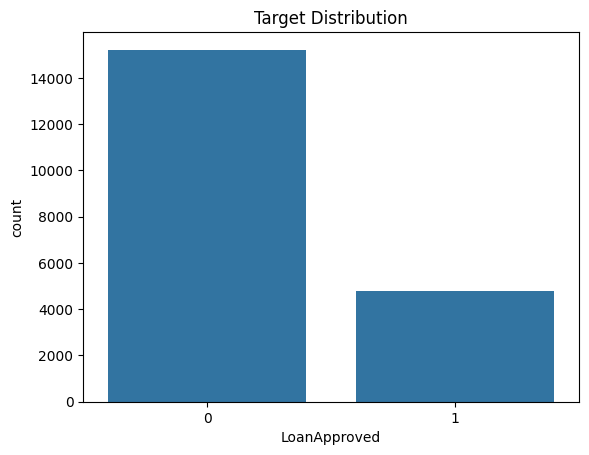

In [ ]:
sns.countplot(x="LoanApproved", data=df)
plt.title("Target Distribution")
plt.show()

9: Distribution Plots

In [ ]:
df.describe()

,Age,AnnualIncome,CreditScore,Experience,LoanAmount,LoanDuration,NumberOfDependents,MonthlyDebtPayments,CreditCardUtilizationRate,NumberOfOpenCreditLines,...,MonthlyIncome,UtilityBillsPaymentHistory,JobTenure,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio,LoanApproved,RiskScore
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,...,20000.000000,20000.000000,20000.000000,2.000000e+04,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
mean,39.752600,59161.473550,571.612400,17.522750,24882.867800,54.057000,1.517300,454.292700,0.286381,3.023350,...,4891.715521,0.799918,5.002650,7.229432e+04,0.239124,0.239110,911.607052,0.402182,0.239000,50.766780
std,11.622713,40350.845168,50.997358,11.316836,13427.421217,24.664857,1.386325,240.507609,0.159793,1.736161,...,3296.771598,0.120665,2.236804,1.179200e+05,0.035509,0.042205,674.583473,0.338924,0.426483,7.778262
min,18.000000,15000.000000,343.000000,0.000000,3674.000000,12.000000,0.000000,50.000000,0.000974,0.000000,...,1250.000000,0.259203,0.000000,1.000000e+03,0.130101,0.113310,97.030193,0.016043,0.000000,28.800000
25%,32.000000,31679.000000,540.000000,9.000000,15575.000000,36.000000,0.000000,286.000000,0.160794,2.000000,...,2629.583333,0.727379,3.000000,8.734750e+03,0.213889,0.209142,493.763700,0.179693,0.000000,46.000000
50%,40.000000,48566.000000,578.000000,17.000000,21914.500000,48.000000,1.000000,402.000000,0.266673,3.000000,...,4034.750000,0.820962,5.000000,3.285550e+04,0.236157,0.235390,728.511452,0.302711,0.000000,52.000000
75%,48.000000,74391.000000,609.000000,25.000000,30835.000000,72.000000,2.000000,564.000000,0.390634,4.000000,...,6163.000000,0.892333,6.000000,8.882550e+04,0.261533,0.265532,1112.770759,0.509214,0.000000,56.000000
max,80.000000,485341.000000,712.000000,61.000000,184732.000000,120.000000,5.000000,2919.000000,0.917380,13.000000,...,25000.000000,0.999433,16.000000,2.603208e+06,0.405029,0.446787,10892.629520,4.647657,1.000000,84.000000


EDA Visualization

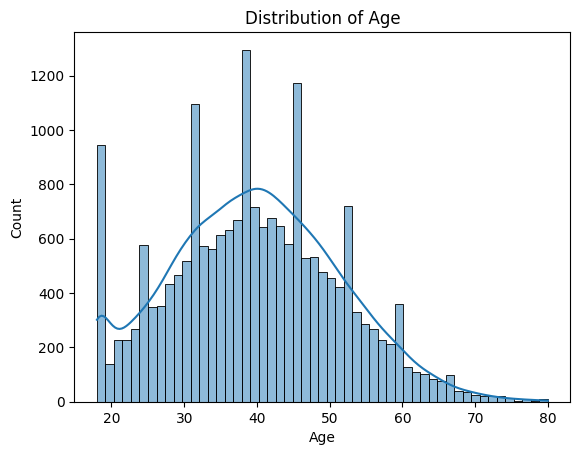

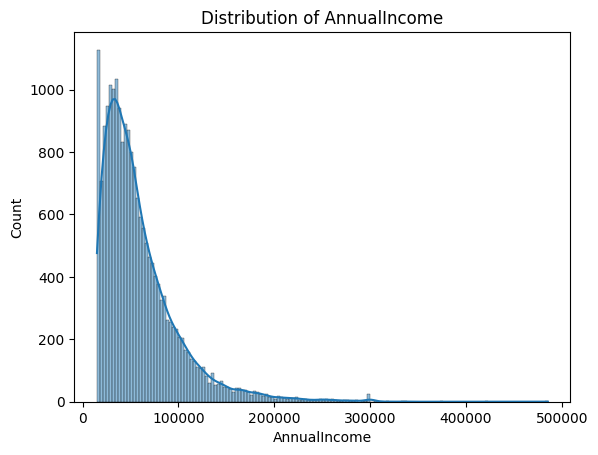

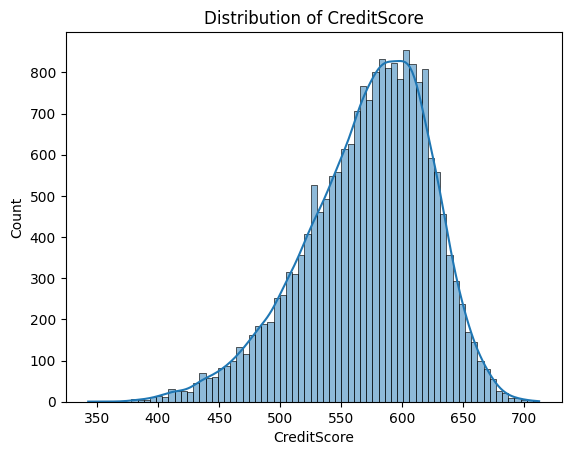

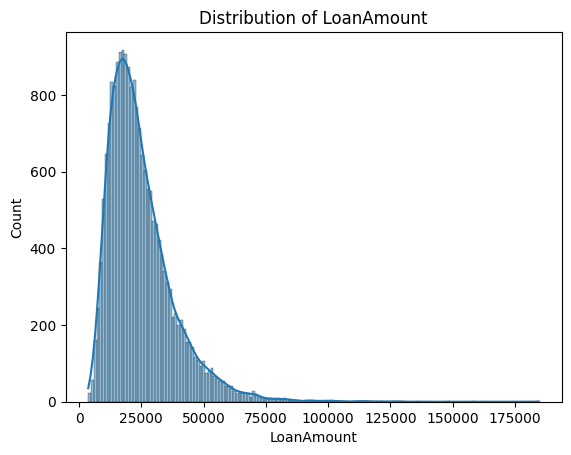

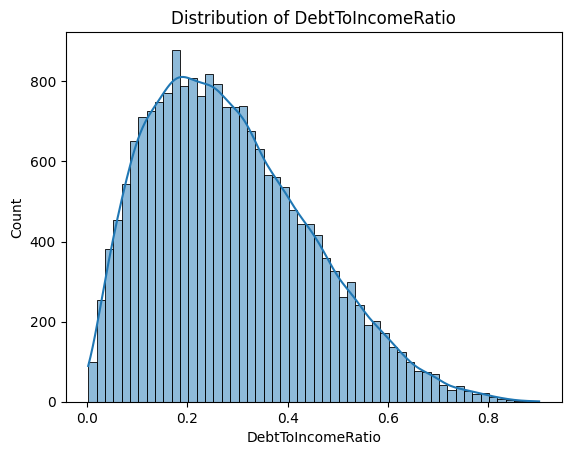

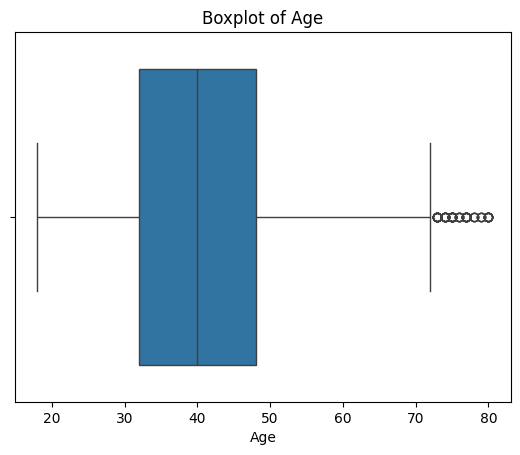

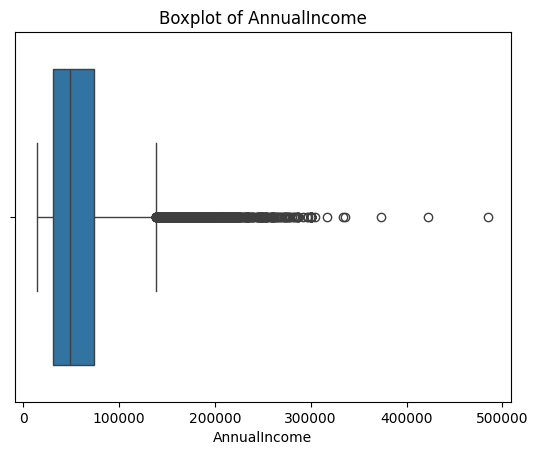

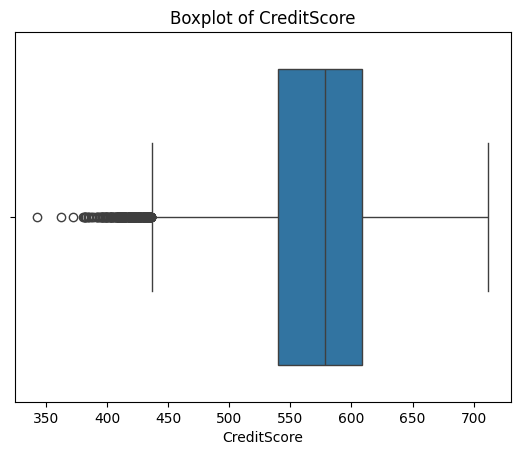

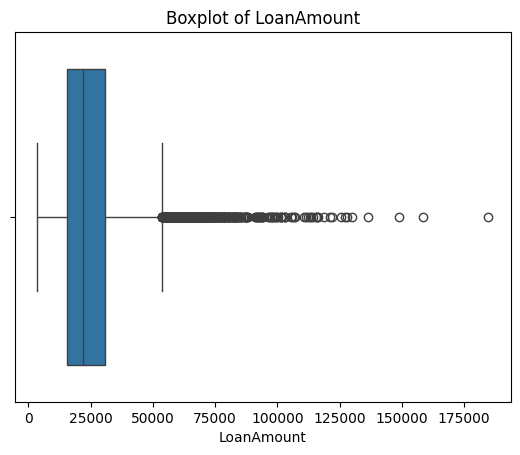

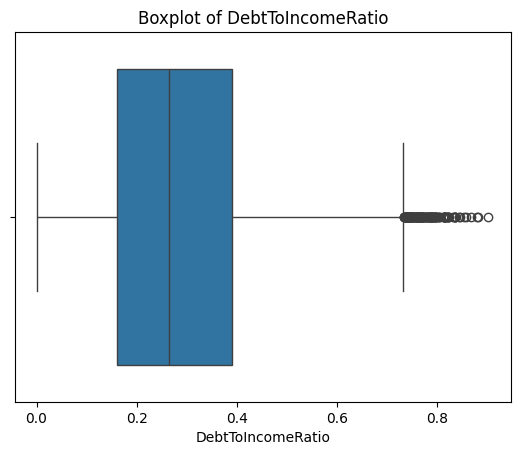

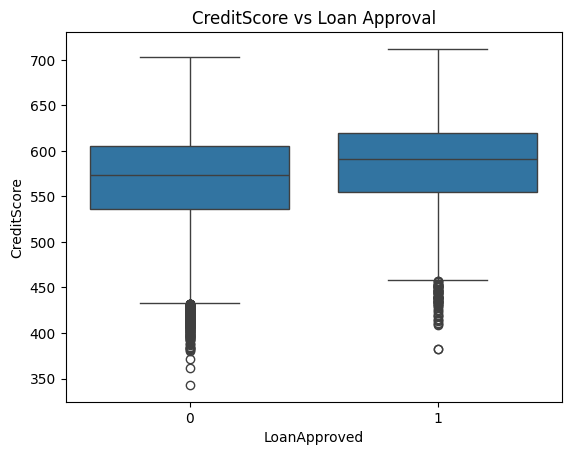

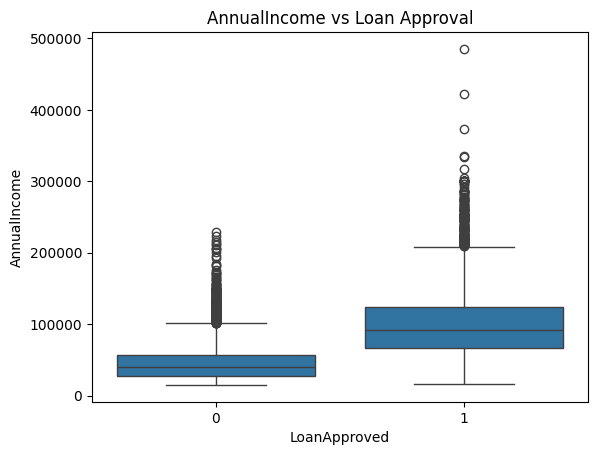

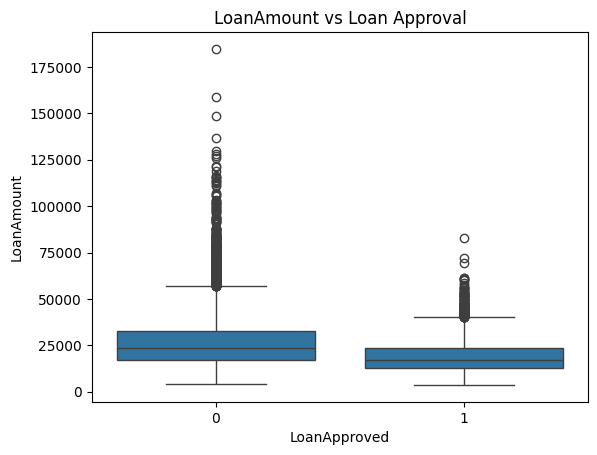

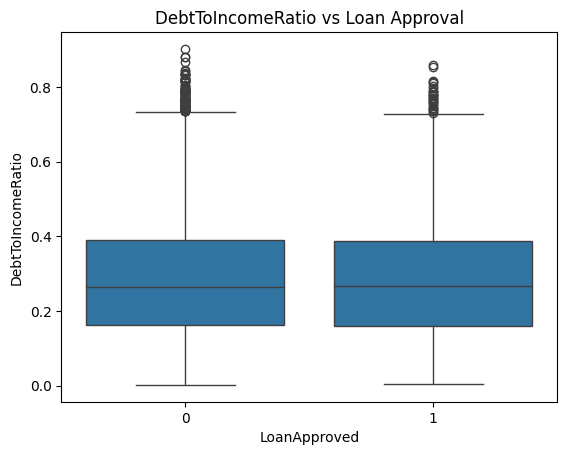

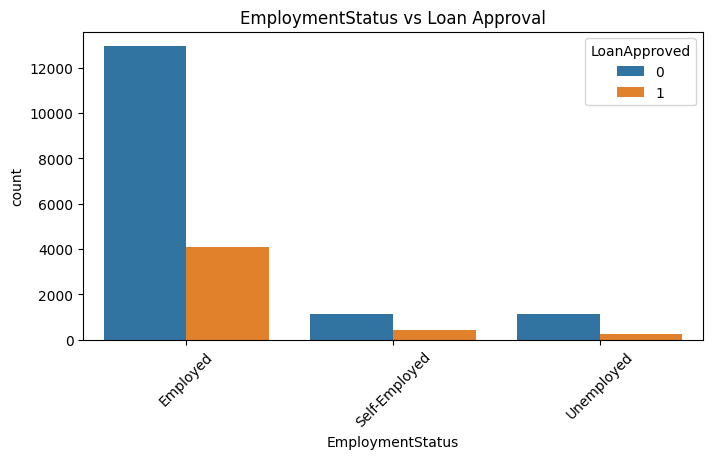

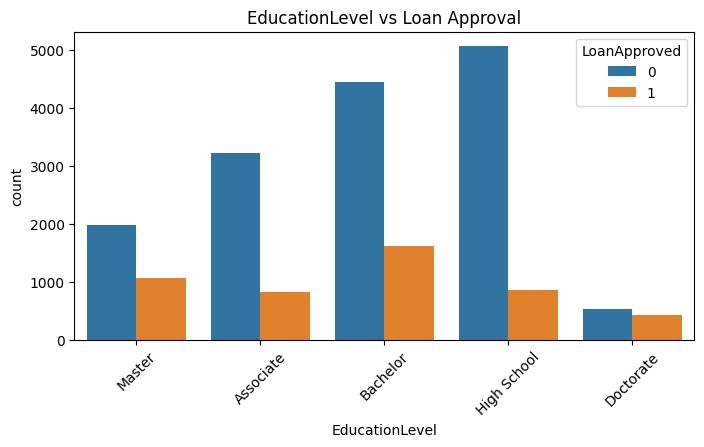

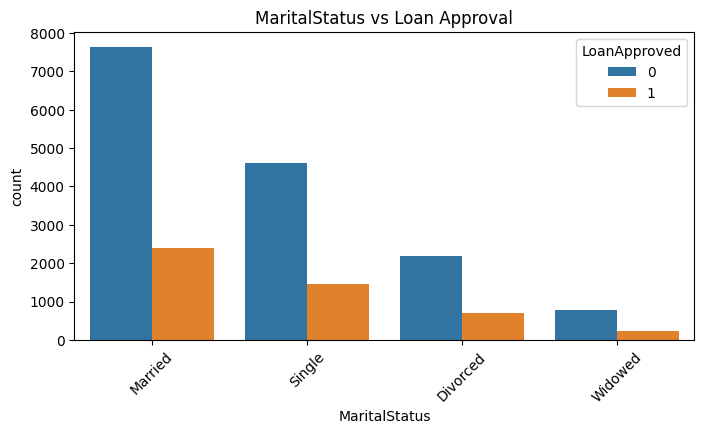

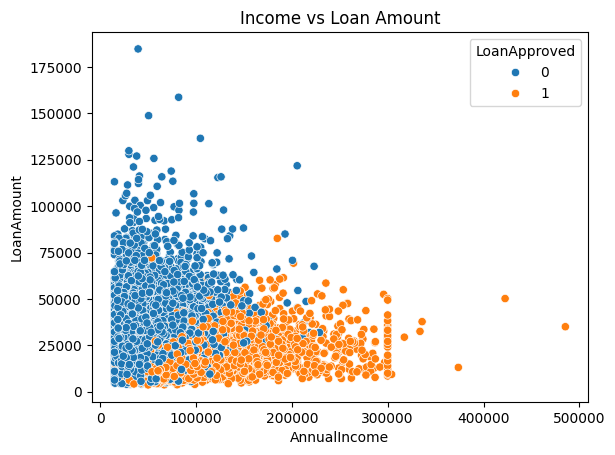

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Histograms
num_cols = ["Age", "AnnualIncome", "CreditScore", "LoanAmount", "DebtToIncomeRatio"]

for col in num_cols:
    plt.figure()
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

# 2. Boxplots (Outliers)
for col in num_cols:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

# 3. Feature vs Target (Boxplots)
features = ["CreditScore", "AnnualIncome", "LoanAmount", "DebtToIncomeRatio"]

for col in features:
    plt.figure()
    sns.boxplot(x="LoanApproved", y=col, data=df)
    plt.title(f"{col} vs Loan Approval")
    plt.show()

# 4. Categorical vs Target
cat_cols = ["EmploymentStatus", "EducationLevel", "MaritalStatus"]

for col in cat_cols:
    plt.figure(figsize=(8,4))
    sns.countplot(x=col, hue="LoanApproved", data=df)
    plt.xticks(rotation=45)
    plt.title(f"{col} vs Loan Approval")
    plt.show()

# 5. Scatter Plot
plt.figure()
sns.scatterplot(x="AnnualIncome", y="LoanAmount", hue="LoanApproved", data=df)
plt.title("Income vs Loan Amount")
plt.show()

10: Correlation Heatmap

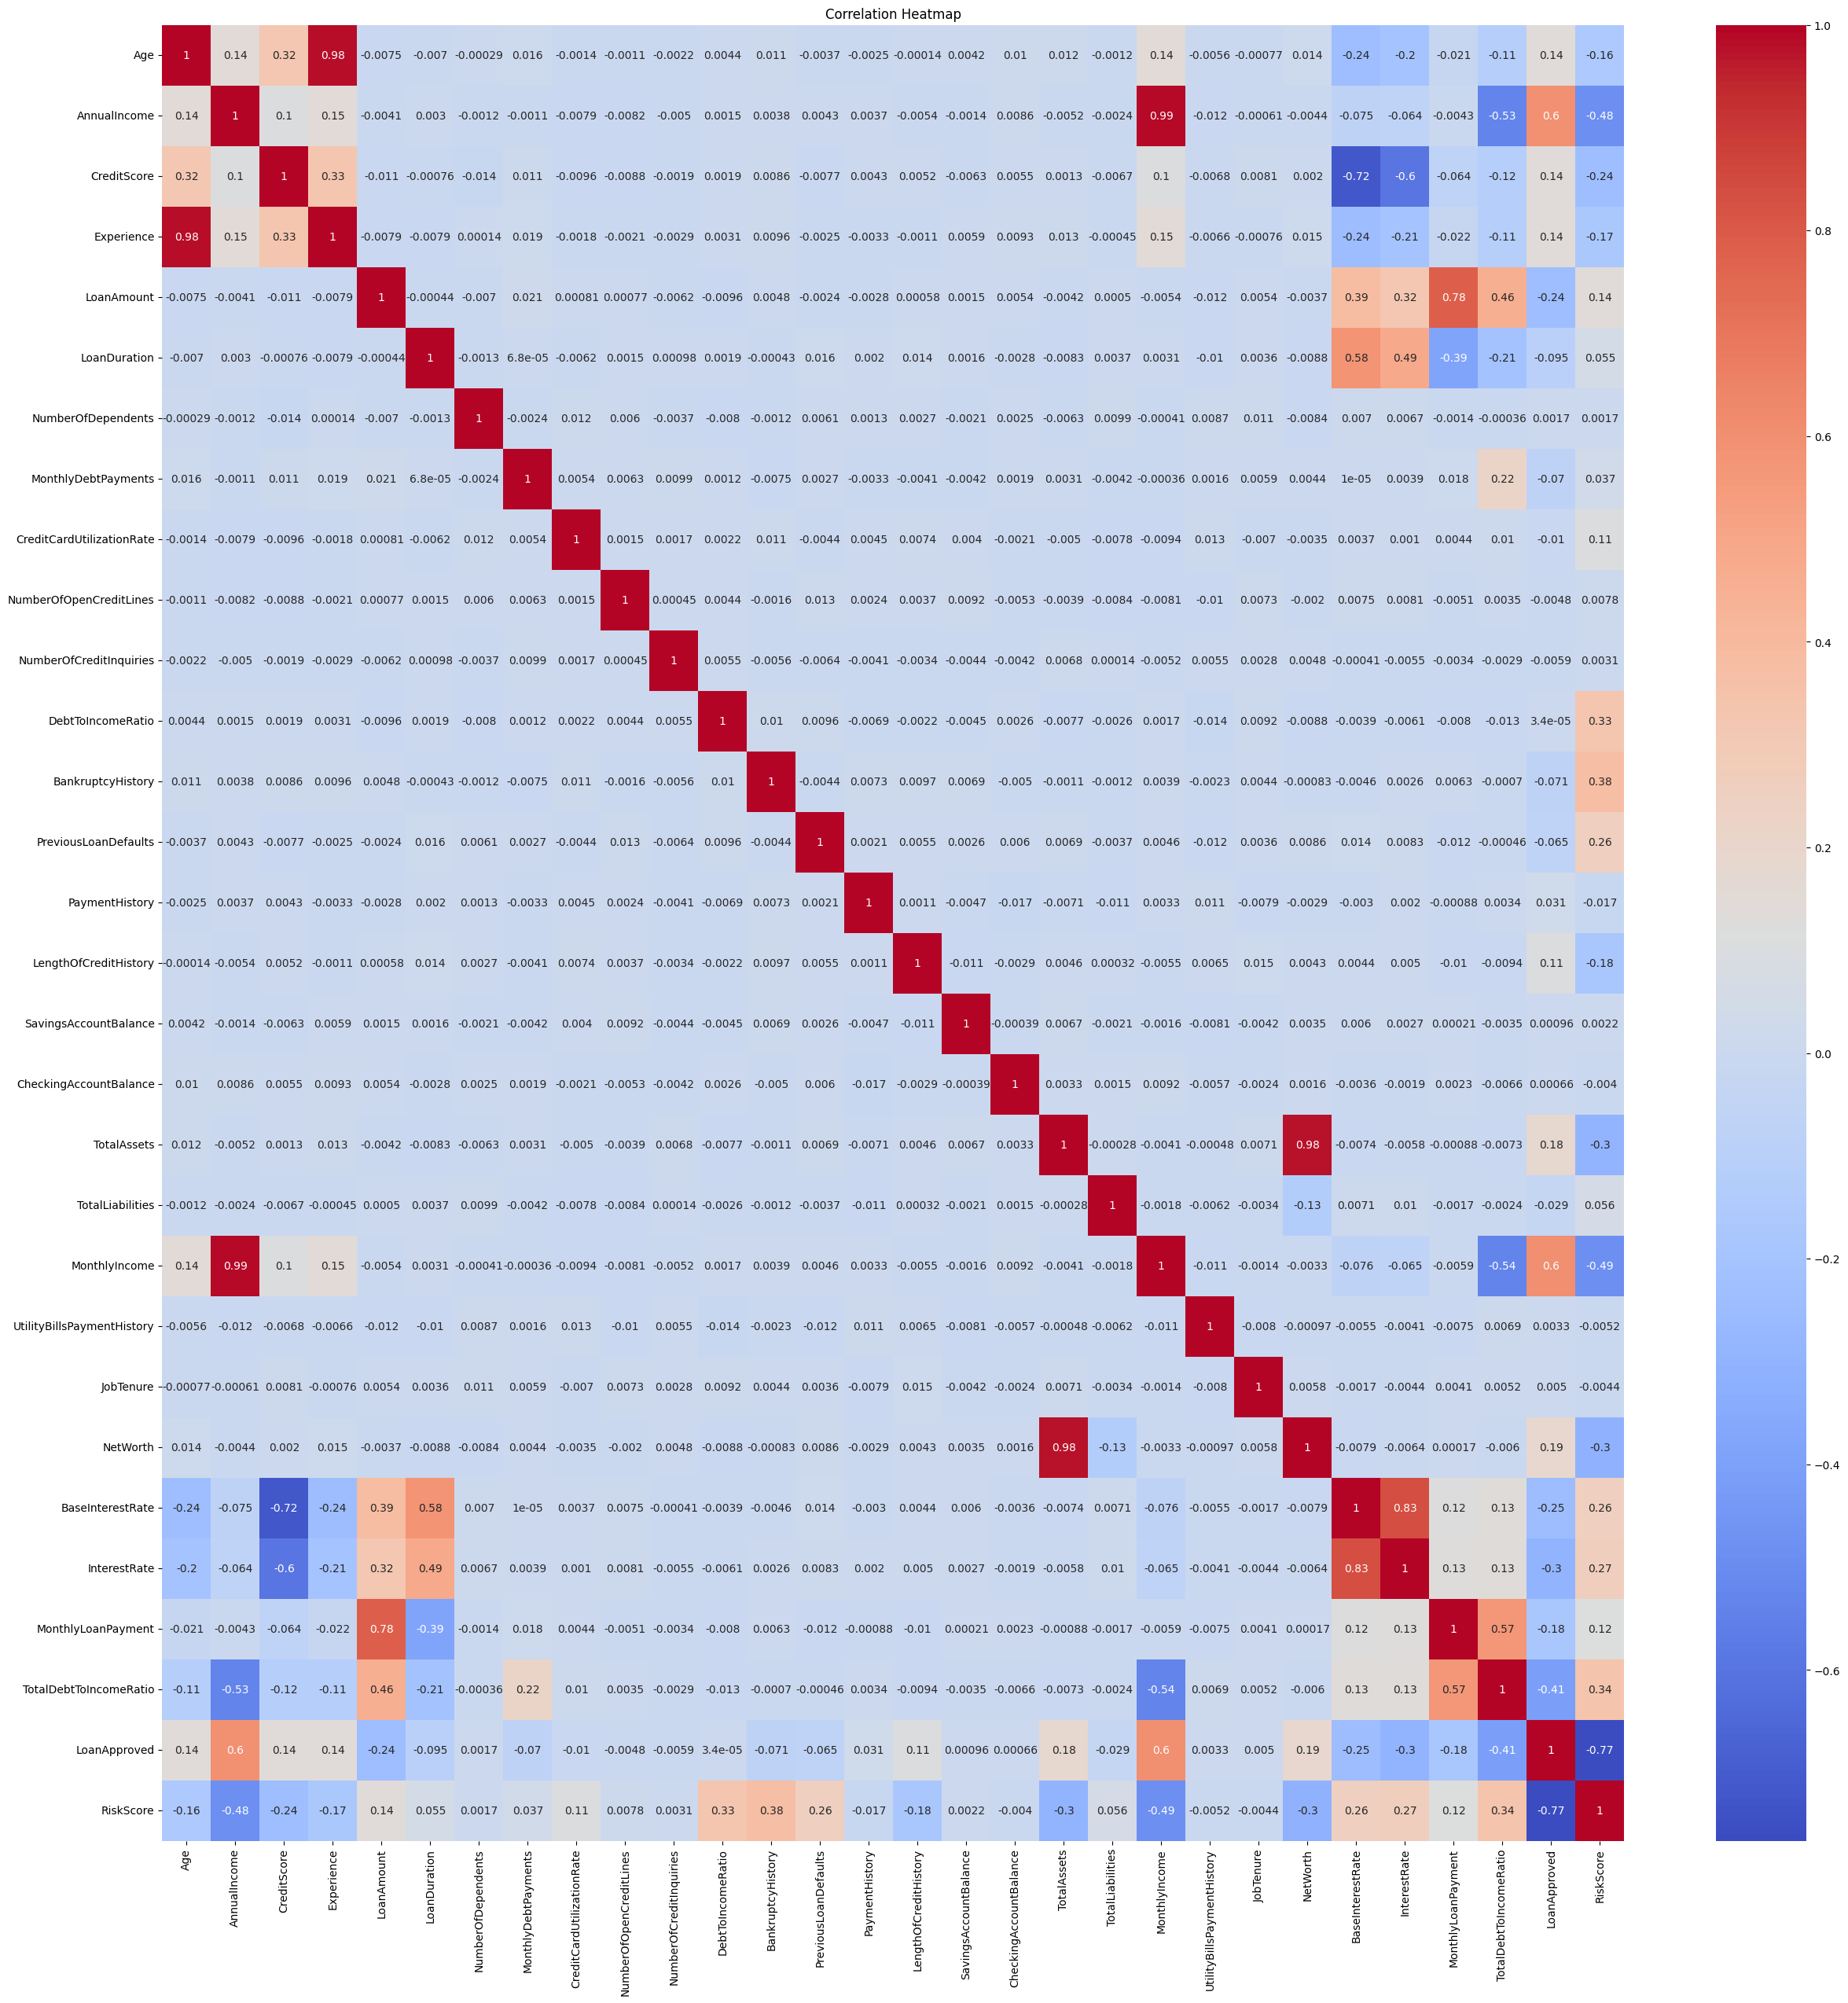

In [ ]:
plt.figure(figsize=(30,30))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

11: Drop Duplicates

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.drop_duplicates(inplace=True)

----------------------------------------------------------------------------------------------------------------

**STAGE 2**

1: Copy Dataset

In [ ]:
data = df.copy()

2: Drop Irrelevant Columns

In [ ]:
data.drop(columns=["ApplicationDate"], inplace=True)

3: Feature Engineering

In [ ]:
# Financial ratios
data["Income_to_Loan"] = data["AnnualIncome"] / (data["LoanAmount"] + 1)
data["Debt_to_Assets"] = data["TotalLiabilities"] / (data["TotalAssets"] + 1)
data["NetWorth_to_Income"] = data["NetWorth"] / (data["AnnualIncome"] + 1)

# Risk indicators
data["High_DTI"] = (data["DebtToIncomeRatio"] > 0.4).astype(int)
data["Low_Credit"] = (data["CreditScore"] < 600).astype(int)

# Stability indicators
data["Job_Stability"] = data["JobTenure"] / (data["Age"] + 1)
data["Experience_Level"] = data["Experience"] / (data["Age"] + 1)

# Loan burden
data["Loan_Burden"] = data["MonthlyLoanPayment"] / (data["MonthlyIncome"] + 1)

4: Split Features & Target

In [ ]:
X = data.drop(["LoanApproved"], axis=1)
y = data["LoanApproved"]

Remove RiskScore

In [ ]:
X = X.drop(columns=["RiskScore"])

In [ ]:
leakage_cols = [
    "MonthlyLoanPayment",
    "TotalDebtToIncomeRatio",
    "BaseInterestRate",
    "InterestRate"
]

X = X.drop(columns=leakage_cols)

5: Encode Categorical Variables

In [ ]:
X = pd.get_dummies(X, drop_first=True)

6: Train-Test Split

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

7: Scaling

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

8: Handle Imbalance

In [ ]:
from imblearn.combine import SMOTETomek

smt = SMOTETomek(random_state=42)
X_train_res, y_train_res = smt.fit_resample(X_train_scaled, y_train)

print(y_train_res.value_counts())

LoanApproved
0    12154
1    12154
Name: count, dtype: int64


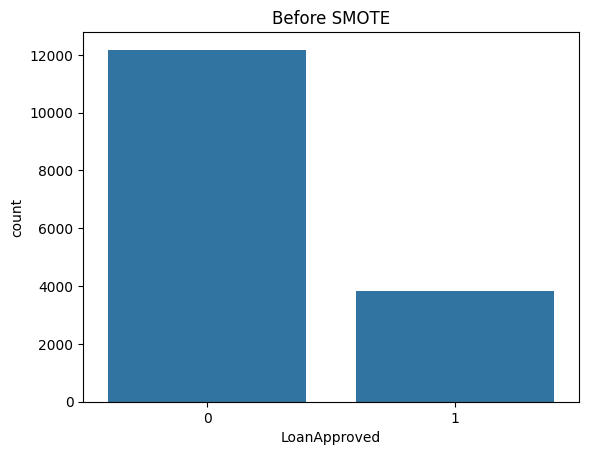

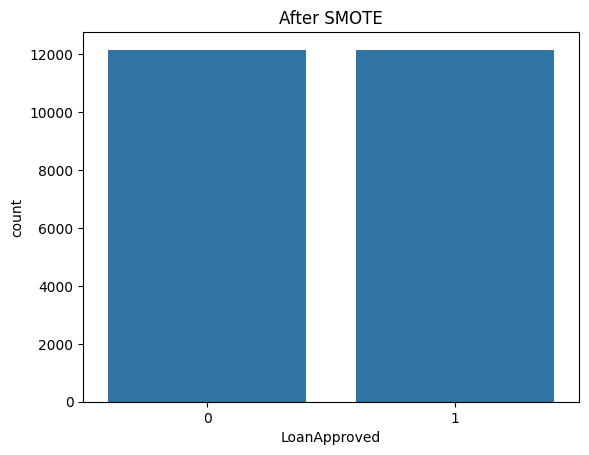

In [ ]:

plt.figure()
sns.countplot(x=y_train)
plt.title("Before SMOTE")
plt.show()

plt.figure()
sns.countplot(x=y_train_res)
plt.title("After SMOTE")
plt.show()

9: Balanced Dataset After SMOTE

In [ ]:
print(X.dtypes)

Age                                 int64
AnnualIncome                        int64
CreditScore                         int64
Experience                          int64
LoanAmount                          int64
LoanDuration                        int64
NumberOfDependents                  int64
MonthlyDebtPayments                 int64
CreditCardUtilizationRate         float64
NumberOfOpenCreditLines             int64
NumberOfCreditInquiries             int64
DebtToIncomeRatio                 float64
BankruptcyHistory                   int64
PreviousLoanDefaults                int64
PaymentHistory                      int64
LengthOfCreditHistory               int64
SavingsAccountBalance               int64
CheckingAccountBalance              int64
TotalAssets                         int64
TotalLiabilities                    int64
MonthlyIncome                     float64
UtilityBillsPaymentHistory        float64
JobTenure                           int64
NetWorth                          

---------------------------------------------------------------------------------------------------------------

**STAGE 3**

1: Train XGBoost

In [ ]:
from xgboost import XGBClassifier

scale_pos_weight = len(y_train[y_train==0]) / len(y_train[y_train==1])

xgb_model = XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    eval_metric="logloss",
    random_state=42
)

xgb_model.fit(X_train_res, y_train_res)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=500, n_jobs=None,
              num_parallel_tree=None, ...)

2: Predict Probabilities

In [ ]:
y_probs = xgb_model.predict_proba(X_test_scaled)[:, 1]

3: Find Best Threshold

In [ ]:
from sklearn.metrics import precision_recall_curve
import numpy as np

precision, recall, thresholds = precision_recall_curve(y_test, y_probs)

f1_scores = 2 * (precision * recall) / (precision + recall + 1e-8)
best_idx = np.argmax(f1_scores)

best_threshold = thresholds[best_idx]

print("Best Threshold:", best_threshold)
print("Best F1 Score:", f1_scores[best_idx])

Best Threshold: 0.5921393
Best F1 Score: 0.8530757448768121


4: Final Evaluation

In [ ]:
from sklearn.metrics import accuracy_score, f1_score, classification_report

y_pred = (y_probs > best_threshold).astype(int)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9275
F1 Score: 0.8524923702950152
              precision    recall  f1-score   support

           0       0.96      0.94      0.95      3044
           1       0.83      0.88      0.85       956

    accuracy                           0.93      4000
   macro avg       0.90      0.91      0.90      4000
weighted avg       0.93      0.93      0.93      4000



MODEL EVALUATION PLOTS

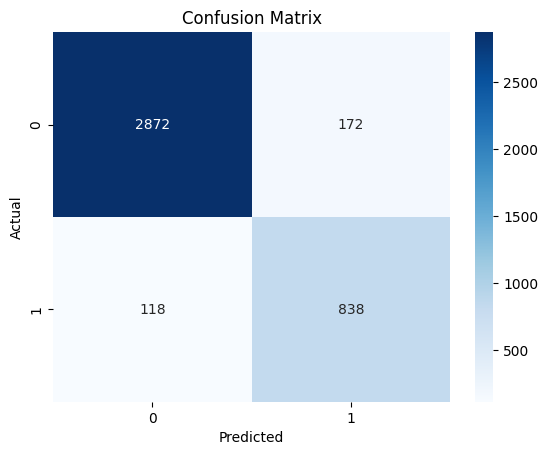

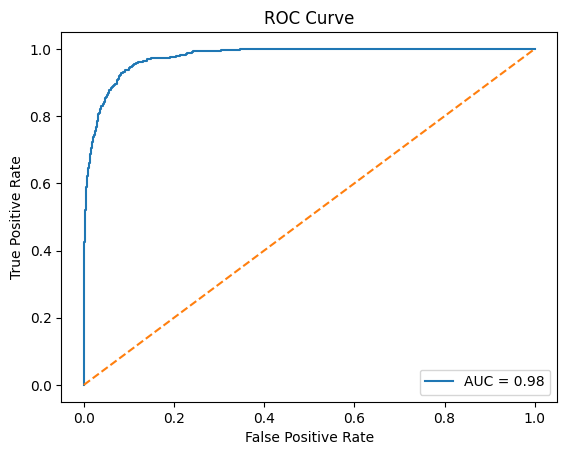

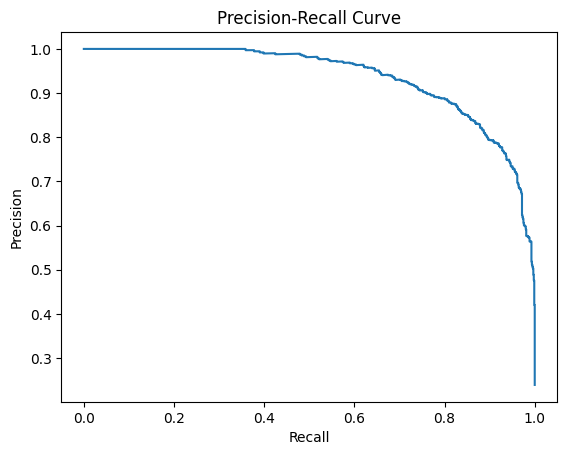

In [ ]:
from sklearn.metrics import confusion_matrix, roc_curve, auc

# 1. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# 2. ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

# 3. Precision-Recall Curve
plt.figure()
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

FEATURE IMPORTANCE

<Figure size 1000x800 with 0 Axes>

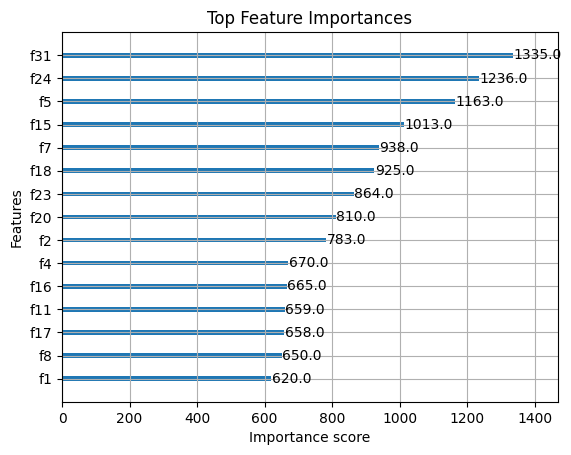

In [ ]:
from xgboost import plot_importance

plt.figure(figsize=(10,8))
plot_importance(xgb_model, max_num_features=15)
plt.title("Top Feature Importances")
plt.show()

---------------------------------------------------------------------------------------------------------------

**STAGE 4**

Convert back to DataFrame

In [ ]:
X_test_df = pd.DataFrame(X_test_scaled, columns=X.columns)

1: Install SHAP

In [ ]:
!pip install shap

2: Initialize Explainer

In [ ]:
import shap

explainer = shap.Explainer(xgb_model, X_train_res)
shap_values = explainer(X_test_df)

100%|===================| 3988/4000 [02:55<00:00]       

3: Compute SHAP Values

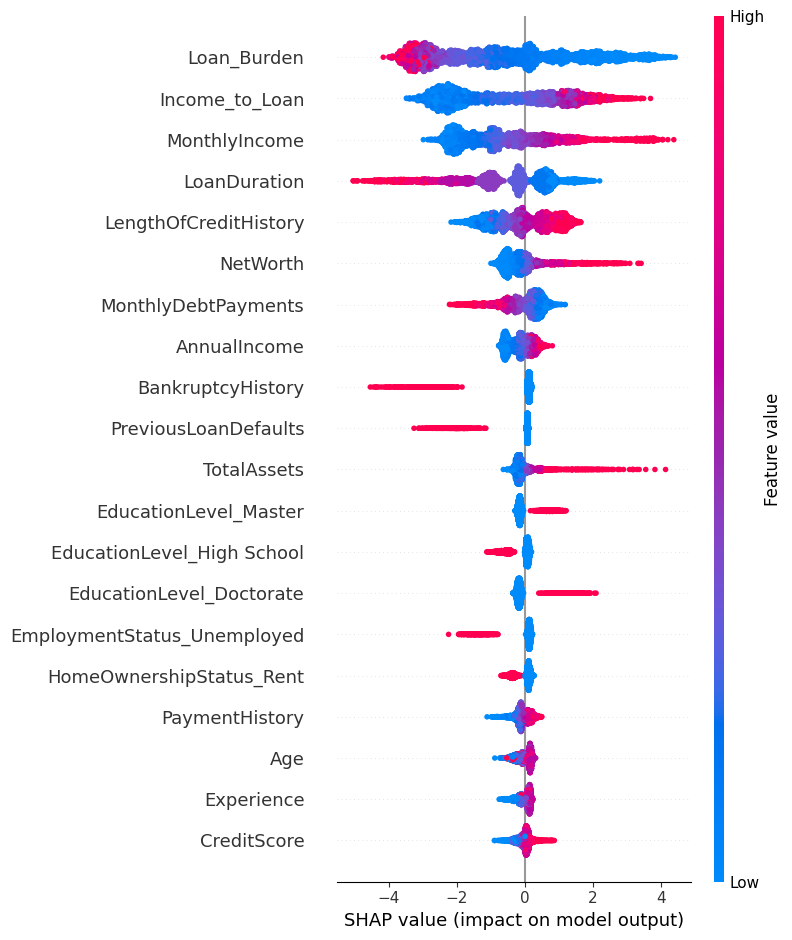

In [ ]:
shap.summary_plot(shap_values, X_test_df)

4: Global Feature Importance

Bar Plot

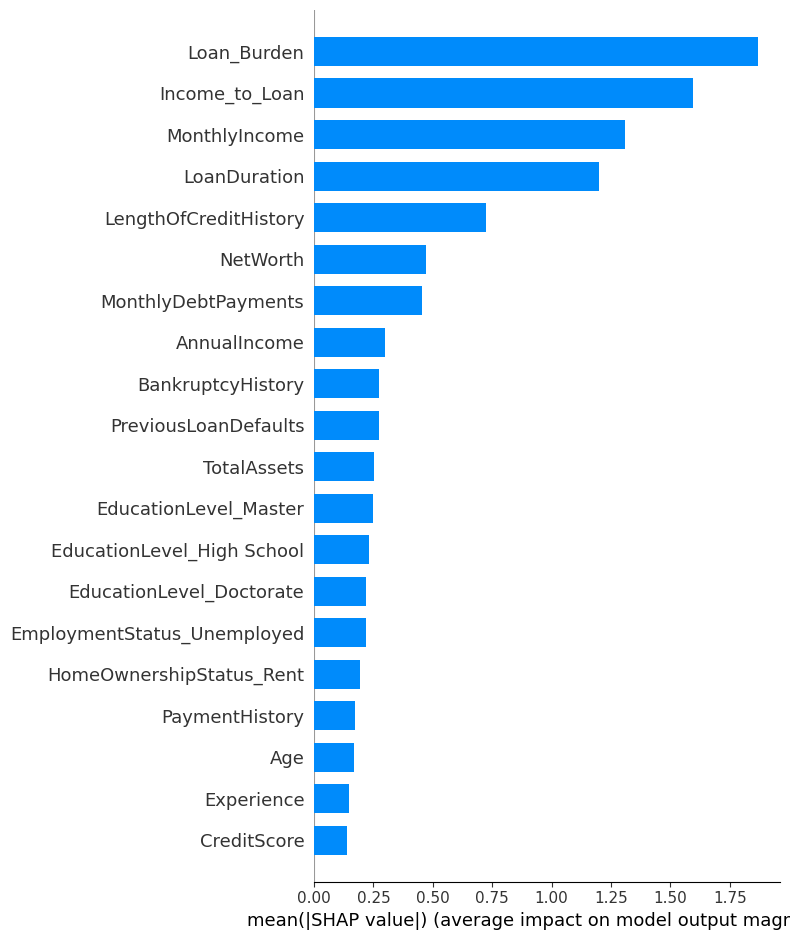

In [ ]:
shap.summary_plot(shap_values, X_test_df, plot_type="bar")

5: Individual Prediction Explanation

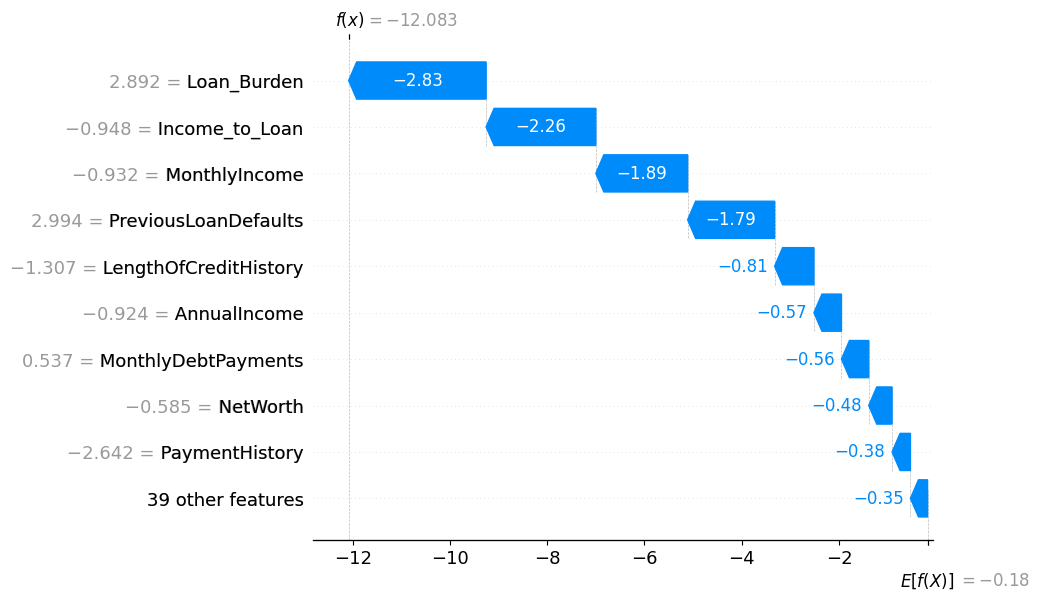

In [ ]:
sample_index = 0
shap.plots.waterfall(shap_values[sample_index])

ADVANCED SHAP

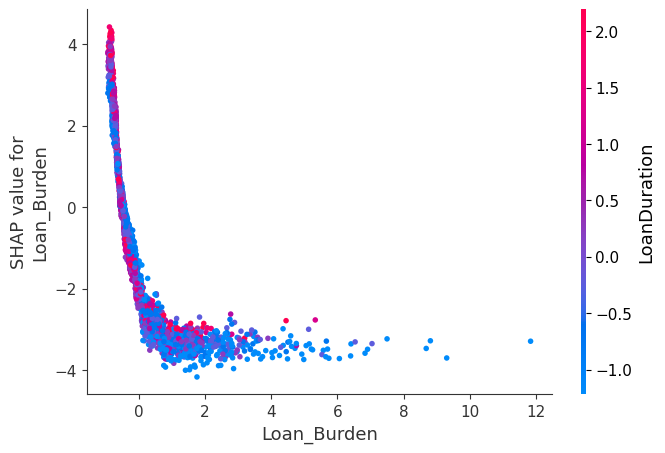

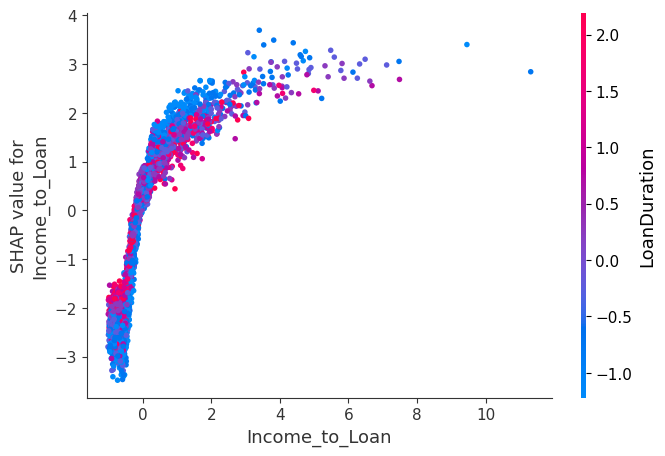

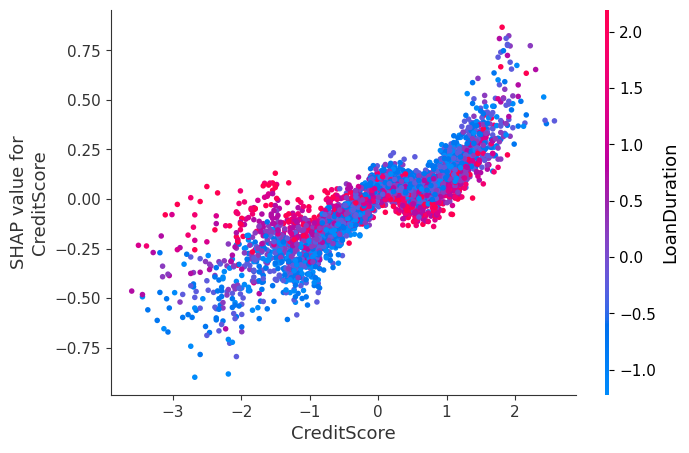

In [ ]:
import shap

top_features = ["Loan_Burden", "Income_to_Loan", "CreditScore"]

for feature in top_features:
    shap.dependence_plot(feature, shap_values.values, X_test_df)

Confusion Matrix

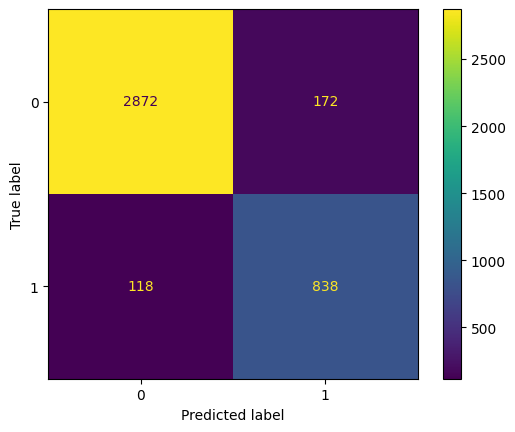

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

---------------------------------------------------------------------------------------------------------------

**STAGE 5**

1: Extract Top Features

In [ ]:
def get_top_factors(shap_row, feature_names, top_n=5):
    values = shap_row.values
    pairs = list(zip(feature_names, values))
    pairs = sorted(pairs, key=lambda x: abs(x[1]), reverse=True)
    return pairs[:top_n]

top_factors = get_top_factors(shap_values[0], X.columns)
top_factors

[('Loan_Burden', np.float64(-2.826302980916371)),
 ('Income_to_Loan', np.float64(-2.255991144312866)),
 ('MonthlyIncome', np.float64(-1.8873237646659253)),
 ('PreviousLoanDefaults', np.float64(-1.7884328563210874)),
 ('LengthOfCreditHistory', np.float64(-0.8088948557317781))]

2: Convert to Human Explanation

In [ ]:
def shap_to_text(factors):
    text = "Main factors affecting your loan decision:\n"
    for f, v in factors:
        if v > 0:
            text += f"- {f} is increasing risk\n"
        else:
            text += f"- {f} is reducing risk\n"
    return text

print(shap_to_text(top_factors))

Main factors affecting your loan decision:
- Loan_Burden is reducing risk
- Income_to_Loan is reducing risk
- MonthlyIncome is reducing risk
- PreviousLoanDefaults is reducing risk
- LengthOfCreditHistory is reducing risk



3: Risk Interpretation

In [ ]:
def interpret_risk(pred):
    return "Loan Approved " if pred == 1 else "Loan Rejected "

4: Smart Recommendations

In [ ]:
def generate_recommendations(user):
    rec = []

    if user["CreditScore"] < 650:
        rec.append("Improve your credit score.")

    if user["DebtToIncomeRatio"] > 0.4:
        rec.append("Reduce your debt obligations.")

    if user["MonthlyLoanPayment"] > user["MonthlyIncome"] * 0.3:
        rec.append("Loan burden is high, consider a smaller loan.")

    if user["NumberOfCreditInquiries"] > 5:
        rec.append("Avoid too many credit inquiries.")

    if len(rec) == 0:
        rec.append("Your financial profile looks strong.")

    return rec

---------------------------------------------------------------------------------------------------------------

STAGE 6

1: Mount Google Drive (for data saving)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


2: Multilingual Support

In [ ]:
def translate(text, lang):
    return text

3: DTI Calculator

In [ ]:
def calculate_dti(monthly_debt, monthly_income):
    if monthly_income == 0:
        return 0
    return monthly_debt / monthly_income

4: User Input System

In [ ]:
def get_user_input():

    print("\n Choose Language:")
    print("1. English\n2. Hindi\n3. Telugu\n4. Kannada\n5. Tamil\n6. Malayalam")

    lang_choice = input("Enter choice (1-6): ")

    lang_map = {
        "1": "en", "2": "hi", "3": "te",
        "4": "kn", "5": "ta", "6": "ml"
    }

    lang = lang_map.get(lang_choice, "en")

    print("\n--- Enter User Details ---")

    age = int(input("Enter Age: "))
    income = float(input("Enter Annual Income: "))

    print("\nSelect Credit Score Type:")
    print("1. CIBIL (300–900)\n2. FICO (300–850)")
    credit_type = input("Choice: ")

    if credit_type == "1":
        credit_score = int(input("Enter CIBIL Score: "))
    else:
        credit_score = int(input("Enter FICO Score: "))

    loan_amount = float(input("Enter Loan Amount: "))

    months_employed = int(input("Enter Months Employed: "))
    years_employed = months_employed / 12
    print(f" Equivalent Employment: {years_employed:.2f} years")

    print("\nDo you know your DTI?")
    dti_choice = input("Enter yes/no: ")

    if dti_choice.lower() == "no":
        monthly_income = float(input("Enter Monthly Income: "))
        monthly_debt = float(input("Enter Monthly Debt: "))
        dti = calculate_dti(monthly_debt, monthly_income)
        print(f" Calculated DTI: {dti:.2f}")
    else:
        dti = float(input("Enter DTI Ratio: "))

    num_cards = int(input("Number of Credit Cards: "))
    late_payments = int(input("Late Payments in Last Year: "))

    print("\nEmployment Type:")
    print("1.Full-time 2.Part-time 3.Contract 4.Freelancer 5.Unemployed")
    emp_choice = input("Choice: ")

    emp_map = {
        "1": "Full-time",
        "2": "Part-time",
        "3": "Contract",
        "4": "Self-employed",
        "5": "Unemployed"
    }

    employment_type = emp_map.get(emp_choice, "Full-time")

    return {
        "Age": age,
        "AnnualIncome": income,
        "CreditScore": credit_score,
        "LoanAmount": loan_amount,
        "Experience": int(years_employed),
        "MonthsEmployed": months_employed,
        "DebtToIncomeRatio": dti,
        "NumberOfOpenCreditLines": num_cards,
        "NumberOfCreditInquiries": late_payments,
        "EmploymentStatus": employment_type,
        "Language": lang
    }

5: Preprocessing

In [ ]:
def preprocess_input(user_input, X_columns, scaler):

    df_input = pd.DataFrame([user_input])

    # Estimated financials
    df_input["SavingsAccountBalance"] = df_input["AnnualIncome"] * 0.2
    df_input["TotalAssets"] = df_input["AnnualIncome"] * 2
    df_input["TotalLiabilities"] = df_input["LoanAmount"]
    df_input["NetWorth"] = df_input["TotalAssets"] - df_input["TotalLiabilities"]

    df_input["MonthlyIncome"] = df_input["AnnualIncome"] / 12
    df_input["MonthlyLoanPayment"] = df_input["LoanAmount"] / 60

    # Feature engineering
    df_input["Income_to_Loan"] = df_input["AnnualIncome"] / (df_input["LoanAmount"] + 1)
    df_input["Debt_to_Assets"] = df_input["TotalLiabilities"] / (df_input["TotalAssets"] + 1)
    df_input["NetWorth_to_Income"] = df_input["NetWorth"] / (df_input["AnnualIncome"] + 1)

    df_input["High_DTI"] = (df_input["DebtToIncomeRatio"] > 0.4).astype(int)
    df_input["Low_Credit"] = (df_input["CreditScore"] < 600).astype(int)

    df_input["Job_Stability"] = df_input["Experience"] / (df_input["Age"] + 1)
    df_input["Experience_Level"] = df_input["Experience"] / (df_input["Age"] + 1)

    df_input["Loan_Burden"] = df_input["MonthlyLoanPayment"] / (df_input["MonthlyIncome"] + 1)

    # Fill missing columns
    for col in X_columns:
        if col not in df_input.columns:
            df_input[col] = 0

    df_input = df_input[X_columns]

    return scaler.transform(df_input)

6: Prediction Function

In [ ]:
def predict_user(user_input):

    processed = preprocess_input(user_input, X.columns, scaler)

    prob = xgb_model.predict_proba(processed)[0][1]
    pred = (prob > best_threshold).astype(int)

    return pred, prob

7: Risk Interpretation

In [ ]:
def interpret_risk(prob):
    if prob >= 0.75:
        return "LOW RISK — LOAN RECOMMENDED"
    elif prob >= 0.5:
        return "MEDIUM RISK — PROCEED WITH CAUTION"
    else:
        return "HIGH RISK — LOAN NOT RECOMMENDED"

8: Recommendations Engine

In [ ]:
def generate_recommendations(user):
    rec = []

    if user["DebtToIncomeRatio"] > 0.4:
        rec.append("Reduce your outstanding debts.")

    if user["NumberOfCreditInquiries"] > 5:
        rec.append("Avoid too many credit inquiries.")

    if user["CreditScore"] < 650:
        rec.append("Improve your credit score.")

    if user["Experience"] < 2:
        rec.append("Maintain stable employment.")

    if len(rec) == 0:
        rec.append("Your financial profile is strong. Maintain your discipline.")

    return rec

9: Final Output Display

In [ ]:
def build_output(prediction, prob, user):

    risk_text = interpret_risk(prob)
    recommendations = generate_recommendations(user)

    print("\n==============================")
    print("CREDIT RISK ANALYSIS")
    print("==============================")

    print(risk_text)
    print(f"Confidence Score: {prob:.2f}")

    print("\n Recommendations:")
    for r in recommendations:
        print(f"- {r}")

10: Save Data to Google Drive

In [ ]:
from datetime import datetime
import os

def save_to_excel(user_input, filename="/content/drive/MyDrive/user_data.xlsx"):

    user_input["Timestamp"] = datetime.now()

    df_new = pd.DataFrame([user_input])

    if os.path.exists(filename):
        df_old = pd.read_excel(filename)
        df_final = pd.concat([df_old, df_new], ignore_index=True)
    else:
        df_final = df_new

    df_final.to_excel(filename, index=False)

11: Run Full System

In [ ]:

user = get_user_input()

prediction, probability = predict_user(user)

build_output(prediction, probability, user)

save_to_excel(user)

print("\n Data saved successfully to Google Drive!")


 Choose Language:
1. English
2. Hindi
3. Telugu
4. Kannada
5. Tamil
6. Malayalam
Enter choice (1-6): 1

--- Enter User Details ---
Enter Age: 32
Enter Annual Income: 1200000

Select Credit Score Type:
1. CIBIL (300–900)
2. FICO (300–850)
Choice: 1
Enter CIBIL Score: 850
Enter Loan Amount: 100000
Enter Months Employed: 22
 Equivalent Employment: 1.83 years

Do you know your DTI?
Enter yes/no: no
Enter Monthly Income: 100000
Enter Monthly Debt: 20000
 Calculated DTI: 0.20
Number of Credit Cards: 1
Late Payments in Last Year: 1

Employment Type:
1.Full-time 2.Part-time 3.Contract 4.Freelancer 5.Unemployed
Choice: 1

CREDIT RISK ANALYSIS
LOW RISK — LOAN RECOMMENDED
Confidence Score: 1.00

 Recommendations:
- Maintain stable employment.

 Data saved successfully to Google Drive!


**STAGE 7**

1: Install Required Libraries

In [ ]:
!pip install streamlit pyngrok shap googletrans==4.0.0-rc1 -q

2: Set ngrok Token

In [ ]:
from pyngrok import ngrok
ngrok.set_auth_token("3Cf4Xo1zJyho18tDOftm0g6ipNc_CnRskTeCfoeZfXczKko8")

3: Create app.py

In [ ]:
%%writefile app.py
import streamlit as st
import pandas as pd
import numpy as np
import pickle
import shap
from datetime import datetime
import os
from googletrans import Translator

translator = Translator()

# ---------------- LOAD MODEL ----------------
model = pickle.load(open("xgb_model.pkl", "rb"))
scaler = pickle.load(open("scaler.pkl", "rb"))
X_columns = pickle.load(open("columns.pkl", "rb"))

best_threshold = 0.5

# ---------------- LANGUAGE ----------------
lang_dict = {
    "English": "en",
    "Hindi": "hi",
    "Telugu": "te",
    "Tamil": "ta",
    "Kannada": "kn",
    "Malayalam": "ml"
}

lang_choice = st.selectbox("🌍 Choose Language", list(lang_dict.keys()))
lang_code = lang_dict[lang_choice]

def t(text):
    try:
        return translator.translate(text, dest=lang_code).text
    except:
        return text

# ---------------- FUNCTIONS ----------------
def calculate_dti(debt, income):
    return debt / income if income > 0 else 0

def preprocess_input(user):
    df = pd.DataFrame([user])

    df["SavingsAccountBalance"] = df["AnnualIncome"] * 0.2
    df["TotalAssets"] = df["AnnualIncome"] * 2
    df["TotalLiabilities"] = df["LoanAmount"]
    df["NetWorth"] = df["TotalAssets"] - df["TotalLiabilities"]

    df["MonthlyIncome"] = df["AnnualIncome"] / 12
    df["MonthlyLoanPayment"] = df["LoanAmount"] / 60

    df["Income_to_Loan"] = df["AnnualIncome"] / (df["LoanAmount"] + 1)
    df["Debt_to_Assets"] = df["TotalLiabilities"] / (df["TotalAssets"] + 1)
    df["NetWorth_to_Income"] = df["NetWorth"] / (df["AnnualIncome"] + 1)

    df["High_DTI"] = (df["DebtToIncomeRatio"] > 0.4).astype(int)
    df["Low_Credit"] = (df["CreditScore"] < 600).astype(int)

    df["Job_Stability"] = df["Experience"] / (df["Age"] + 1)
    df["Experience_Level"] = df["Experience"] / (df["Age"] + 1)

    df["Loan_Burden"] = df["MonthlyLoanPayment"] / (df["MonthlyIncome"] + 1)

    for col in X_columns:
        if col not in df.columns:
            df[col] = 0

    df = df[X_columns]

    return scaler.transform(df), df

def interpret_risk(prob):
    if prob >= 0.75:
        return t("LOW RISK — LOAN RECOMMENDED")
    elif prob >= 0.5:
        return t("MEDIUM RISK — PROCEED WITH CAUTION")
    else:
        return t("HIGH RISK — LOAN NOT RECOMMENDED")

def generate_recommendations(user):
    rec = []

    if user["DebtToIncomeRatio"] > 0.4:
        rec.append(t("Reduce your outstanding debts."))

    if user["NumberOfCreditInquiries"] > 5:
        rec.append(t("Avoid too many credit inquiries."))

    if user["CreditScore"] < 650:
        rec.append(t("Improve your credit score."))

    if user["Experience"] < 2:
        rec.append(t("Maintain stable employment."))

    if len(rec) == 0:
        rec.append(t("Your financial profile is strong."))

    return rec

def save_data(user):
    filename = "user_data.xlsx"
    user["Timestamp"] = datetime.now()

    df_new = pd.DataFrame([user])

    if os.path.exists(filename):
        df_old = pd.read_excel(filename)
        df_new = pd.concat([df_old, df_new])

    df_new.to_excel(filename, index=False)

# ---------------- UI ----------------
st.title("💳 Credit Risk AI")

col1, col2 = st.columns(2)

with col1:
    age = st.slider(t("Age"), 18, 70)
    income = st.number_input(t("Annual Income"))

with col2:
    loan = st.number_input(t("Loan Amount"))
    credit_score = st.slider(t("Credit Score"), 300, 900)

months = st.number_input(t("Months Employed"))
years = months / 12
st.write(t(f"Experience: {years:.2f} years"))

monthly_income = st.number_input(t("Monthly Income"))
monthly_debt = st.number_input(t("Monthly Debt"))

dti = calculate_dti(monthly_debt, monthly_income)
st.write(t(f"DTI: {dti:.2f}"))

cards = st.number_input(t("Number of Credit Cards"))
late = st.number_input(t("Late Payments"))

employment = st.selectbox(
    t("Employment Type"),
    ["Full-time", "Part-time", "Contract", "Self-employed", "Unemployed"]
)

# ---------------- PREDICT ----------------
if st.button(t("Predict")):

    user = {
        "Age": age,
        "AnnualIncome": income,
        "CreditScore": credit_score,
        "LoanAmount": loan,
        "Experience": int(years),
        "MonthsEmployed": months,
        "DebtToIncomeRatio": dti,
        "NumberOfOpenCreditLines": cards,
        "NumberOfCreditInquiries": late,
        "EmploymentStatus": employment
    }

    processed, df_input = preprocess_input(user)

    prob = model.predict_proba(processed)[0][1]

    st.subheader(t("Result"))
    st.success(interpret_risk(prob))
    st.metric(t("Confidence"), f"{prob:.2f}")

    st.subheader(t("Recommendations"))
    for r in generate_recommendations(user):
        st.info(r)




    save_data(user)
    st.success(t("Data saved successfully"))

Overwriting app.py


4: Upload Model Files

In [ ]:
from google.colab import files
files.upload()

Saving xgb_model.pkl to xgb_model (1).pkl
Saving columns.pkl to columns (1).pkl
Saving scaler.pkl to scaler (1).pkl


{'xgb_model (1).pkl': b'\x80\x04\x95k\x03\x00\x00\x00\x00\x00\x00\x8c\x0fxgboost.sklearn\x94\x8c\rXGBClassifier\x94\x93\x94)\x81\x94}\x94(\x8c\x0cn_estimators\x94M\xf4\x01\x8c\tobjective\x94\x8c\x0fbinary:logistic\x94\x8c\tmax_depth\x94K\x06\x8c\nmax_leaves\x94N\x8c\x07max_bin\x94N\x8c\x0bgrow_policy\x94N\x8c\rlearning_rate\x94G?\xa9\x99\x99\x99\x99\x99\x9a\x8c\tverbosity\x94N\x8c\x07booster\x94N\x8c\x0btree_method\x94N\x8c\x05gamma\x94N\x8c\x10min_child_weight\x94N\x8c\x0emax_delta_step\x94N\x8c\tsubsample\x94G?\xec\xcc\xcc\xcc\xcc\xcc\xcd\x8c\x0fsampling_method\x94N\x8c\x10colsample_bytree\x94G?\xe9\x99\x99\x99\x99\x99\x9a\x8c\x11colsample_bylevel\x94N\x8c\x10colsample_bynode\x94N\x8c\treg_alpha\x94N\x8c\nreg_lambda\x94N\x8c\x10scale_pos_weight\x94G@\ty\t\xa3\xe2\x02$\x8c\nbase_score\x94N\x8c\x07missing\x94G\x7f\xf8\x00\x00\x00\x00\x00\x00\x8c\x11num_parallel_tree\x94N\x8c\x0crandom_state\x94K*\x8c\x06n_jobs\x94N\x8c\x14monotone_constraints\x94N\x8c\x17interaction_constraints\x94N\x8

5: Run App

In [ ]:
from pyngrok import ngrok

ngrok.kill()

get_ipython().system_raw('streamlit run app.py &')

print(ngrok.connect(8501))

NgrokTunnel: "https://salute-penknife-aftermath.ngrok-free.dev" -> "http://localhost:8501"
